# Profile Generation Tests

Objective: exercise the attack-profile generation pipeline in one notebook, with emphasis on the new v4 target-zone data path for VAE training.

Use this notebook to:
- generate a small in-memory `random_zones` sample
- inspect target-zone, approach-side, and label coverage
- verify spawn clearance and accessible-envelope placement
- compare multiple convoy layouts
- optionally write a JSONL dataset after the checks look sane


## Workflow

1. Configure sample sizes and seeds.
2. Generate v3 `random_zones` records in memory.
3. Audit distribution coverage and geometry constraints.
4. Plot convoy, target points, and U-boat spawns when plotting is available.
5. Run a multi-layout smoke check.
6. Optionally export JSONL for VAE experiments.

This notebook intentionally does not train the VAE. The goal is to decide whether the data manifold is worth training on.


In [1]:
#Imports
from __future__ import annotations
from collections import Counter
import json
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.audit_attack_profile_dataset import flatten_dataset_records, summarize_flat_rows
from experiments.generate_attack_profile_scaffold import (
    MIN_SPAWN_CLEARANCE_M,
    generate_attack_profile_scaffolds,
    render_profiles_as_jsonl,)
from convoy_sim.target_zones import convoy_frame_and_envelope
from convoy_sim.profile_outcome_audit import (
    OutcomeAuditConfig,
    audit_dataset_outcomes,
    filter_records_by_outcome_gate,
    summarize_outcome_rows,
)
from convoy_sim.profile_generation_viz import (
    FIXED_X_LIMITS,
    U_BOAT_COLOR,
    U_BOAT_EDGE,
    apply_limits,
    combined_limits,
    simple_ship_polygons,
    style_ax,)
from scenarios.convoy_profiles import get_convoy_layout_profile, list_convoy_layout_profiles

PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

## Config

In [3]:
MODE = "random_tactical_v4"
CONVOY_PROFILE = "convoy_layout_1"
COUNT = 500
SEED = 1945
START_INDEX = 1

# Optional export. Leave disabled until the checks below look good.
WRITE_JSONL = False
EXPORT_OUTCOME_GATED_ONLY = False
EXPORT_PATH = PROJECT_ROOT / "data/attack_profiles/synthetic/train_random_tactical_v4.jsonl"

EXPECTED_HIT_FRACTION = 0.65
EXPECTED_NEAR_MISS_FRACTION = 0.25
EXPECTED_INTENTIONAL_MISS_FRACTION = 0.10
MIN_EXPECTED_ZONE_KINDS = 4
MIN_EXPECTED_APPROACH_SIDES = 5
MIN_EXPECTED_SPAWN_REGIONS = 4
PLOT_COLOR_BY = "spawn_region"
PLOT_COLOR_TITLE = "Spawn region"

# Dynamic outcome audit standard: moving convoy_layout_1 with zig-zag evasive motion.
OUTCOME_T_MAX_S = 600.0
OUTCOME_HIT_DT_S = 0.5
OUTCOME_NEAR_MISS_MARGIN_M = 250.0


## Helpers


In [4]:
def build_records(*, mode: str, convoy_profile: str, count: int, seed: int, start_index: int = 1) -> list[dict]:
    profiles, audit_rows = generate_attack_profile_scaffolds(
        mode=mode,
        convoy_profile=convoy_profile,
        count=count,
        seed=seed,
        start_index=start_index,
    )
    rendered = render_profiles_as_jsonl(
        profiles,
        audit_rows=audit_rows,
        seed=seed,
        convoy_profile=convoy_profile,
        accepted_labels=("credible_hit_threat", "credible_near_miss"),
        mode=mode,
    )
    return [json.loads(line) for line in rendered.splitlines() if line.strip()]


def value_counts(rows: list[dict], column: str) -> dict[str, int]:
    return dict(Counter(str(row.get(column, "")) for row in rows if str(row.get(column, ""))))


def count_table(counts: dict[str, int]) -> pd.DataFrame:
    return pd.DataFrame([{"value": key, "count": counts[key]} for key in sorted(counts)])


## Generate Records


In [5]:
start = time.perf_counter()
records = build_records(
    mode=MODE,
    convoy_profile=CONVOY_PROFILE,
    count=int(COUNT),
    seed=int(SEED),
    start_index=int(START_INDEX),
)
elapsed = time.perf_counter() - start

print(f"Generated {len(records):,} records in {elapsed:.2f}s")
# records[0]


Generated 500 records in 47.52s


## Flatten And Summarize

The flat rows mirror `experiments.audit_attack_profile_dataset` outputs, so these views should match the CSV audit if files written later.


In [6]:
flat_rows = flatten_dataset_records(records)
summary = summarize_flat_rows(flat_rows)

summary_view = {
    "profile_count": summary["profile_count"],
    "labels": summary["labels"],
    "target_zone_kinds": summary.get("target_zone_kinds", {}),
    "spawn_regions": summary.get("spawn_regions", {}),
    "inside_convoy_envelope": summary.get("inside_convoy_envelope", {}),
    "approach_sides": summary.get("approach_sides", {}),
    "range_to_target_m": summary.get("range_to_target_m", {}),
    "severity": summary.get("severity", {}),
}
summary_view


{'profile_count': 500,
 'labels': {'credible_hit_threat': 325,
  'credible_near_miss': 125,
  'intentional_miss': 50},
 'target_zone_kinds': {'port_edge': 63,
  'lead_column': 115,
  'interior': 165,
  'starboard_edge': 77,
  'trailing_column': 80},
 'spawn_regions': {'ahead_beam': 122,
  'astern_infiltration': 75,
  'outside_perimeter': 156,
  'beam_attack': 73,
  'inside_columns': 74},
 'inside_convoy_envelope': {'true': 96, 'false': 404},
 'approach_sides': {'ahead': 155,
  'astern': 85,
  'port': 99,
  'starboard_forward_quarter': 14,
  'starboard_aft_quarter': 22,
  'inside_columns': 96,
  'port_forward_quarter': 19,
  'port_aft_quarter': 10},
 'range_to_target_m': {'mean': 2281.9607128894486,
  'min': 452.2979859465322,
  'max': 4797.931578131494},
 'severity': {'mean': 1.2555811388344802,
  'min': 0.01505868491690859,
  'max': 2.991972233283832}}

## Coverage Checks

These assertions are intentionally blunt. If one fails, inspect the tables/plots before changing thresholds.


In [7]:
label_counts = value_counts(flat_rows, "suggested_label")
hit_count = int(label_counts.get("credible_hit_threat", 0))
near_miss_count = int(label_counts.get("credible_near_miss", 0))
intentional_miss_count = int(label_counts.get("intentional_miss", 0))
hit_fraction = hit_count / max(len(flat_rows), 1)
near_miss_fraction = near_miss_count / max(len(flat_rows), 1)
intentional_miss_fraction = intentional_miss_count / max(len(flat_rows), 1)
zone_kind_count = len(value_counts(flat_rows, "target_zone_kind"))
approach_side_count = len(value_counts(flat_rows, "approach_side"))
spawn_region_count = len(value_counts(flat_rows, "spawn_region"))
inside_count = sum(1 for row in flat_rows if bool(row.get("inside_convoy_envelope", False)))

checks = {
    "has_expected_count": len(flat_rows) == COUNT,
    "hit_fraction": hit_fraction,
    "near_miss_fraction": near_miss_fraction,
    "intentional_miss_fraction": intentional_miss_fraction,
    "has_expected_zone_kinds": zone_kind_count >= MIN_EXPECTED_ZONE_KINDS,
    "has_expected_approach_sides": approach_side_count >= MIN_EXPECTED_APPROACH_SIDES,
    "has_expected_spawn_regions": spawn_region_count >= MIN_EXPECTED_SPAWN_REGIONS,
    "has_inside_convoy_spawns": inside_count > 0,
    "no_implausible_labels": set(label_counts) <= {"credible_hit_threat", "credible_near_miss", "intentional_miss"},
    "all_have_intent": all("intent" in record for record in records),
}
checks


{'has_expected_count': True,
 'hit_fraction': 0.65,
 'near_miss_fraction': 0.25,
 'intentional_miss_fraction': 0.1,
 'has_expected_zone_kinds': True,
 'has_expected_approach_sides': True,
 'has_expected_spawn_regions': True,
 'has_inside_convoy_spawns': True,
 'no_implausible_labels': True,
 'all_have_intent': True}

In [8]:
assert checks["has_expected_count"]
assert abs(checks["hit_fraction"] - EXPECTED_HIT_FRACTION) <= 0.02
assert abs(checks["near_miss_fraction"] - EXPECTED_NEAR_MISS_FRACTION) <= 0.02
assert abs(checks["intentional_miss_fraction"] - EXPECTED_INTENTIONAL_MISS_FRACTION) <= 0.02
assert checks["has_expected_zone_kinds"]
assert checks["has_expected_approach_sides"]
assert checks["has_expected_spawn_regions"]
assert checks["has_inside_convoy_spawns"]
assert checks["no_implausible_labels"]
assert checks["all_have_intent"]


## Spawn Location Distribution Tables


In [9]:
distribution_tables = {
    "labels": count_table(value_counts(flat_rows, "suggested_label")),
    "target_zone_kind": count_table(value_counts(flat_rows, "target_zone_kind")),
    "spawn_region": count_table(value_counts(flat_rows, "spawn_region")),
    "inside_convoy_envelope": count_table(value_counts(flat_rows, "inside_convoy_envelope")),
    "approach_side": count_table(value_counts(flat_rows, "approach_side")),
    "approach_lane": count_table(value_counts(flat_rows, "approach_lane")),
}
distribution_tables["spawn_region"]


,value,count
0,ahead_beam,122
1,astern_infiltration,75
2,beam_attack,73
3,inside_columns,74
4,outside_perimeter,156


In [10]:
distribution_tables["target_zone_kind"]


,value,count
0,interior,165
1,lead_column,115
2,port_edge,63
3,starboard_edge,77
4,trailing_column,80


## Spawn Location Distribution Plots

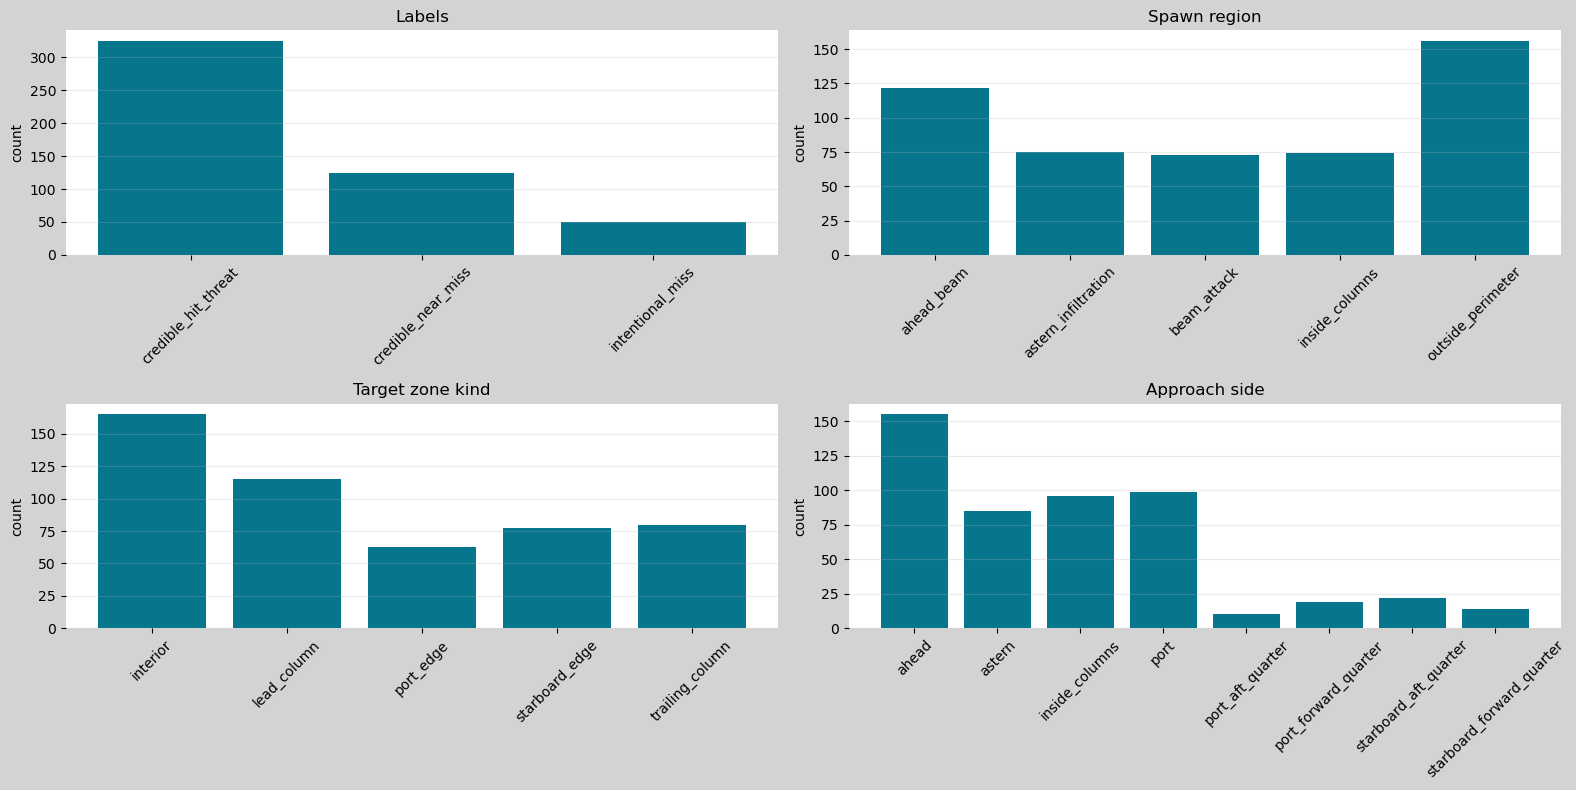

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), facecolor="lightgrey")
plot_specs = [
    ("suggested_label", "Labels"),
    ("spawn_region", "Spawn region"),
    ("target_zone_kind", "Target zone kind"),
    ("approach_side", "Approach side"),
]
for ax, (column, title) in zip(axes.ravel(), plot_specs):
    counts = value_counts(flat_rows, column)
    labels = sorted(counts)
    ax.bar(labels, [counts[label] for label in labels], color="#06768d")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()


## Spawn Locations Plots

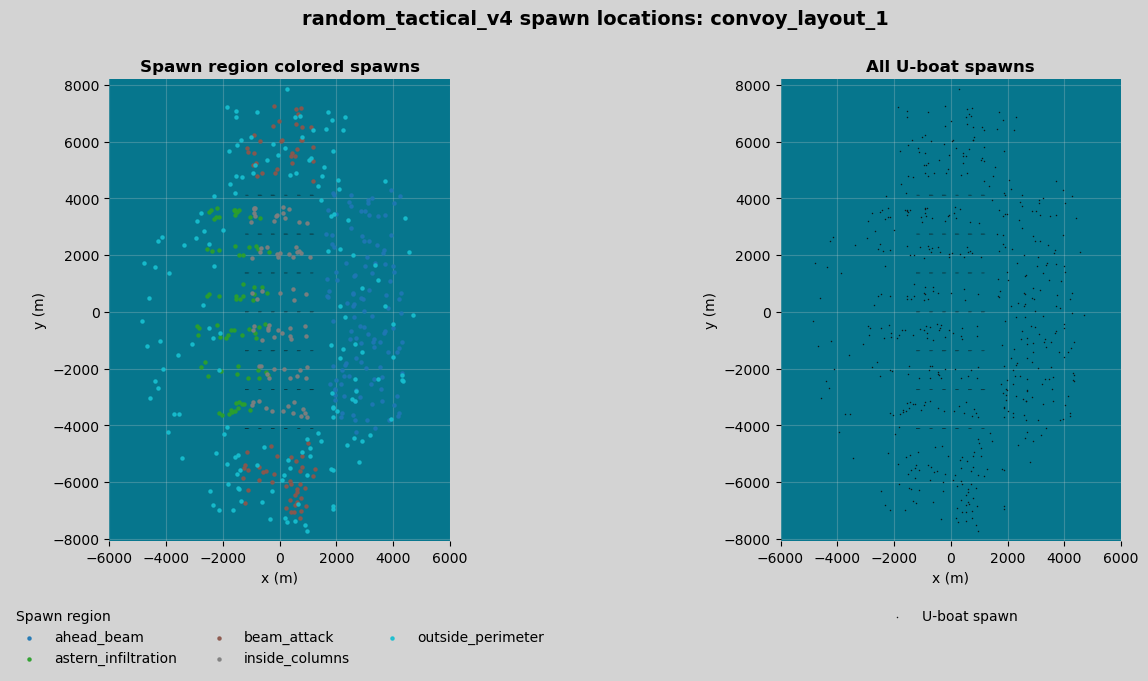

In [12]:
spawn_df = pd.DataFrame(flat_rows)
spawn_df["u_pos"] = spawn_df[["u_pos_x", "u_pos_y"]].values.tolist()
spawn_points = np.vstack(spawn_df["u_pos"].to_list()) if len(spawn_df) else None
ships_spawn_plot = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
shared_limits = combined_limits(ships_spawn_plot, extra_points=spawn_points, pad=350.0)
color_column = PLOT_COLOR_BY if PLOT_COLOR_BY in spawn_df and value_counts(flat_rows, PLOT_COLOR_BY) else "target_zone_kind"
color_title = PLOT_COLOR_TITLE if color_column == PLOT_COLOR_BY else "Target zone kind"
color_values = sorted(str(value) for value in spawn_df[color_column].unique() if str(value))
color_map = dict(zip(color_values, plt.cm.tab10(np.linspace(0, 1, len(color_values)))))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="lightgrey")

style_ax(axes[0], f"{color_title} colored spawns")
simple_ship_polygons(axes[0], ships_spawn_plot)
for value in color_values:
    value_xy = np.vstack(spawn_df.loc[spawn_df[color_column].astype(str) == value, "u_pos"].to_list())
    axes[0].scatter(
        value_xy[:, 0],
        value_xy[:, 1],
        c=[color_map[value]],
        s=5,
        alpha=0.90,
        zorder=2,
        label=value,
    )
apply_limits(axes[0], shared_limits, fixed_x_limits=FIXED_X_LIMITS)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
leg = axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=3, frameon=False, title=color_title)
if leg is not None:
    leg._legend_box.align = "left"

style_ax(axes[1], "All U-boat spawns")
simple_ship_polygons(axes[1], ships_spawn_plot)
if len(spawn_df):
    spawn_xy = np.vstack(spawn_df["u_pos"].to_list())
    axes[1].scatter(
        spawn_xy[:, 0],
        spawn_xy[:, 1],
        c=U_BOAT_COLOR,
        # edgecolors=U_BOAT_EDGE,
        linewidths=0.35,
        s=0.5,
        alpha=1,
        zorder=2,
        label="U-boat spawn",
    )
apply_limits(axes[1], shared_limits, fixed_x_limits=FIXED_X_LIMITS)
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("y (m)")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=1, frameon=False)

fig.suptitle(f"{MODE} spawn locations: {CONVOY_PROFILE}", fontsize=14, weight="bold")
fig.subplots_adjust(bottom=0.22, top=0.88, wspace=0.18)
# plt.savefig("V4_Data_Generation_Test.png")
plt.show()


## Geometry Checks

This verifies two practical constraints:
- U-boat spawn is at least `MIN_SPAWN_CLEARANCE_M` from every ship center.
- Spawn is outside the convoy local envelope on at least one access axis.


In [13]:
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
frame, envelope, _local_positions = convoy_frame_and_envelope(ships)
ship_positions = np.asarray([np.asarray(ship.position, dtype=float) for ship in ships], dtype=float)

spawn_xy = np.asarray([[float(row["u_pos_x"]), float(row["u_pos_y"])] for row in flat_rows], dtype=float)
clearances = np.min(np.linalg.norm(spawn_xy[:, None, :] - ship_positions[None, :, :], axis=2), axis=1)
spawn_local = np.asarray([frame.world_to_local(point) for point in spawn_xy], dtype=float)
outside_envelope = (
    (spawn_local[:, 0] < envelope.min_x)
    | (spawn_local[:, 0] > envelope.max_x)
    | (spawn_local[:, 1] < envelope.min_y)
    | (spawn_local[:, 1] > envelope.max_y)
)
intent_inside = np.asarray([bool(row.get("inside_convoy_envelope", False)) for row in flat_rows], dtype=bool)
computed_inside = ~outside_envelope

checked_rows = []
for idx, row in enumerate(flat_rows):
    enriched = dict(row)
    enriched["clearance_m"] = float(clearances[idx])
    enriched["spawn_local_x"] = float(spawn_local[idx, 0])
    enriched["spawn_local_y"] = float(spawn_local[idx, 1])
    enriched["outside_envelope"] = bool(outside_envelope[idx])
    enriched["computed_inside_convoy_envelope"] = bool(computed_inside[idx])
    checked_rows.append(enriched)

geometry_summary = {
    "min_clearance_m": float(clearances.min()),
    "clearance_failures": int((clearances < MIN_SPAWN_CLEARANCE_M).sum()),
    "inside_spawns": int(computed_inside.sum()),
    "outside_spawns": int(outside_envelope.sum()),
    "inside_flag_mismatches": int((intent_inside != computed_inside).sum()),
    "min_range_to_target_m": float(min(float(row["range_to_target_m"]) for row in flat_rows)),
    "max_range_to_target_m": float(max(float(row["range_to_target_m"]) for row in flat_rows)),
}
geometry_summary


{'min_clearance_m': 262.1473384786572,
 'clearance_failures': 0,
 'inside_spawns': 96,
 'outside_spawns': 404,
 'inside_flag_mismatches': 0,
 'min_range_to_target_m': 452.2979859465322,
 'max_range_to_target_m': 4797.931578131494}

## Ships Hit Audit (Run Profiles Through Sim Pipeline)

This runs the generated profiles through the standard moving-convoy outcome path: `convoy_layout_1`, zig-zag evasive convoy motion, moving U-boats, and generated `uniform_divergent` spreads.


In [14]:
standard_checks = {
    "convoy_layout_1": CONVOY_PROFILE == "convoy_layout_1",
    "moving_u_boats": all(str(record["profile"].get("u_boat_mode")) == "moving" for record in records),
    "uniform_divergent_spreads": all(str(record["profile"].get("spread_doctrine")) == "uniform_divergent" for record in records),
}
assert standard_checks["convoy_layout_1"]
assert standard_checks["moving_u_boats"]
assert standard_checks["uniform_divergent_spreads"]

outcome_cfg = OutcomeAuditConfig(
    t_max_s=float(OUTCOME_T_MAX_S),
    hit_dt_s=float(OUTCOME_HIT_DT_S),
    near_miss_margin_m=float(OUTCOME_NEAR_MISS_MARGIN_M),
    max_hits_per_torpedo=1,
    zigzag_enabled=True,
)

start = time.perf_counter()
outcome_rows = audit_dataset_outcomes(records, ships=ships, rng_seed=int(SEED), cfg=outcome_cfg)
outcome_seconds = time.perf_counter() - start
outcome_df = pd.DataFrame(outcome_rows)
outcome_summary = summarize_outcome_rows(outcome_rows)
outcome_summary["seconds"] = round(outcome_seconds, 3)
outcome_summary["standard_checks"] = standard_checks
records_with_outcomes = [
    {**record, "outcome": dict(outcome)}
    for record, outcome in zip(records, outcome_rows)
]
gated_records_with_outcomes = filter_records_by_outcome_gate(records_with_outcomes)
outcome_summary["gated_record_count"] = len(gated_records_with_outcomes)
outcome_summary


{'profile_count': 500,
 'actual_outcome_labels': {'credible_hit_threat': 325,
  'credible_near_miss': 125,
  'miss': 50},
 'intended_labels': {'credible_hit_threat': 325,
  'credible_near_miss': 125,
  'intentional_miss': 50},
 'outcome_match_rate': 1.0,
 'outcome_gate_pass_count': 500,
 'intended_target_hit_rate': 0.65,
 'any_ship_hit_rate': 0.65,
 'mean_hits': 2.078,
 'mean_unique_ships_hit': 1.116,
 'mean_closest_intended_target_distance_m': 69.80477838422557,
 'mean_closest_any_ship_distance_m': 129.01201822141033,
 'seconds': 15.056,
 'standard_checks': {'convoy_layout_1': True,
  'moving_u_boats': True,
  'uniform_divergent_spreads': True},
 'gated_record_count': 500}

In [15]:
pd.crosstab(
    outcome_df["intended_label"],
    outcome_df["actual_outcome_label"],
    margins=True,
)


actual_outcome_label,credible_hit_threat,credible_near_miss,miss,All
intended_label,,,,
credible_hit_threat,325,0,0,325
credible_near_miss,0,125,0,125
intentional_miss,0,0,50,50
All,325,125,50,500


In [16]:
def outcome_group_table(column: str) -> pd.DataFrame:
    rows = []
    for value, group in outcome_df.groupby(column, dropna=False):
        rows.append({
            column: value,
            "count": int(len(group)),
            "match_rate": float(group["outcome_matches_intent"].mean()),
            "intended_target_hit_rate": float(group["intended_target_hit"].mean()),
            "any_ship_hit_rate": float(group["any_ship_hit"].mean()),
            "mean_hits": float(group["n_hits"].mean()),
            "mean_closest_intended_target_m": float(group["closest_intended_target_distance_m"].replace([np.inf, -np.inf], np.nan).mean()),
            "mean_closest_any_ship_m": float(group["closest_any_ship_distance_m"].mean()),
        })
    return pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)

outcome_by_spawn_region = outcome_group_table("spawn_region")
outcome_by_spawn_region


,spawn_region,count,match_rate,intended_target_hit_rate,any_ship_hit_rate,mean_hits,mean_closest_intended_target_m,mean_closest_any_ship_m
0,outside_perimeter,156,1.0,0.647436,0.647436,1.980769,75.250694,139.880204
1,ahead_beam,122,1.0,0.672131,0.672131,2.057377,52.383752,118.782638
2,astern_infiltration,75,1.0,0.613333,0.613333,2.000000,112.145680,127.045469
3,inside_columns,74,1.0,0.608108,0.608108,2.256757,32.160119,58.544198
4,beam_attack,73,1.0,0.698630,0.698630,2.219178,75.042951,196.336089


In [17]:
outcome_by_approach_side = outcome_group_table("approach_side")
outcome_by_target_zone_kind = outcome_group_table("target_zone_kind")
outcome_by_approach_side


,approach_side,count,match_rate,intended_target_hit_rate,any_ship_hit_rate,mean_hits,mean_closest_intended_target_m,mean_closest_any_ship_m
0,ahead,155,1.0,0.677419,0.677419,2.083871,45.452269,114.987461
1,port,99,1.0,0.676768,0.676768,2.131313,66.907063,199.334355
2,inside_columns,96,1.0,0.583333,0.583333,2.177083,47.302231,66.367291
3,astern,85,1.0,0.670588,0.670588,1.976471,119.734883,130.450524
4,starboard_aft_quarter,22,1.0,0.590909,0.590909,1.727273,64.152756,155.567565
5,port_forward_quarter,19,1.0,0.578947,0.578947,1.894737,187.909222,236.358636
6,starboard_forward_quarter,14,1.0,0.714286,0.714286,2.571429,22.052466,53.326895
7,port_aft_quarter,10,1.0,0.600000,0.600000,1.800000,23.422049,82.942004


In [18]:
outcome_by_target_zone_kind


,target_zone_kind,count,match_rate,intended_target_hit_rate,any_ship_hit_rate,mean_hits,mean_closest_intended_target_m,mean_closest_any_ship_m
0,interior,165,1.0,0.715152,0.715152,2.363636,19.609080,66.728671
1,lead_column,115,1.0,0.678261,0.678261,2.165217,25.771410,115.406813
2,trailing_column,80,1.0,0.587500,0.587500,1.862500,101.627773,123.769591
3,starboard_edge,77,1.0,0.623377,0.623377,1.961039,118.313452,191.277823
4,port_edge,63,1.0,0.539683,0.539683,1.587302,160.148549,247.524367


In [19]:
failure_cols = [
    "profile_id",
    "intended_label",
    "actual_outcome_label",
    "outcome_matches_intent",
    "spawn_region",
    "approach_side",
    "target_zone_kind",
    "target_ship_ids",
    "hit_ship_ids",
    "intended_target_hit",
    "closest_intended_target_distance_m",
    "closest_any_ship_distance_m",
    "closest_any_ship_id",
    "n_hits",
]
failures = outcome_df.loc[~outcome_df["outcome_matches_intent"], failure_cols].copy()
failures.sort_values(
    ["intended_label", "closest_intended_target_distance_m", "closest_any_ship_distance_m"],
    ascending=[True, False, False],
).head(25)


,profile_id,intended_label,actual_outcome_label,outcome_matches_intent,spawn_region,approach_side,target_zone_kind,target_ship_ids,hit_ship_ids,intended_target_hit,closest_intended_target_distance_m,closest_any_ship_distance_m,closest_any_ship_id,n_hits


In [20]:
assert geometry_summary["clearance_failures"] == 0
assert geometry_summary["inside_flag_mismatches"] == 0


## Worst Rows

Near-misses should dominate the highest-error rows. If hit threats appear here with high error, inspect spread and target geometry.


In [21]:
worst_cols = [
    "profile_id",
    "suggested_label",
    "intended_label",
    "target_zone_kind",
    "spawn_region",
    "inside_convoy_envelope",
    "approach_side",
    "range_to_target_m",
    "nearest_ship_clearance_m",
    "target_aspect_deg",
    "bearing_error_deg",
    "spread_deg",
    "severity",
]
worst_rows = [
    {key: row[key] for key in worst_cols}
    for row in sorted(checked_rows, key=lambda item: float(item["severity"]), reverse=True)[:20]
]
pd.DataFrame(worst_rows)


,profile_id,suggested_label,intended_label,target_zone_kind,spawn_region,inside_convoy_envelope,approach_side,range_to_target_m,nearest_ship_clearance_m,target_aspect_deg,bearing_error_deg,spread_deg,severity
0,T000142,credible_hit_threat,credible_hit_threat,interior,inside_columns,True,inside_columns,858.479616,582.522336,69.313045,2.493310,6.0,2.991972
1,T000229,credible_hit_threat,credible_hit_threat,port_edge,astern_infiltration,False,astern,1021.344638,696.443816,29.005594,2.491888,6.0,2.990265
2,T000287,credible_hit_threat,credible_hit_threat,trailing_column,astern_infiltration,False,astern,1308.097864,1140.768151,39.232654,2.473699,5.5,2.968439
3,T000158,credible_hit_threat,credible_hit_threat,lead_column,ahead_beam,False,ahead,3367.764582,2102.302577,51.456336,2.470987,3.5,2.965185
4,T000230,credible_hit_threat,credible_hit_threat,interior,ahead_beam,False,ahead,4700.499128,2934.392077,44.518497,2.470519,3.0,2.964623
5,T000177,credible_hit_threat,credible_hit_threat,interior,outside_perimeter,False,ahead,2527.453953,1543.581074,38.938544,2.460538,4.0,2.952646
6,T000278,credible_hit_threat,credible_hit_threat,port_edge,beam_attack,False,port,1784.770409,1535.744903,59.977893,2.447539,3.0,2.937046
7,T000186,credible_hit_threat,credible_hit_threat,lead_column,ahead_beam,False,ahead,4186.428749,766.110571,79.449015,2.443255,3.0,2.931906
8,T000075,credible_hit_threat,credible_hit_threat,starboard_edge,inside_columns,True,inside_columns,574.991987,576.664097,69.945359,2.437406,3.0,2.924887
9,T000093,credible_hit_threat,credible_hit_threat,starboard_edge,beam_attack,False,port,1593.874468,1588.711249,88.536577,2.431659,4.5,2.917990


## Multi-Layout Smoke Test

This checks that v3 generation is not hardwired to one convoy profile.


In [22]:
layout_rows = []
for layout_name in list_convoy_layout_profiles():
    layout_count = 128 if layout_name == "small_demo" else 256
    start = time.perf_counter()
    layout_records = build_records(
        mode=MODE,
        convoy_profile=layout_name,
        count=layout_count,
        seed=SEED,
        start_index=START_INDEX,
    )
    layout_flat = flatten_dataset_records(layout_records)
    layout_rows.append(
        {
            "convoy_profile": layout_name,
            "count": len(layout_flat),
            "seconds": round(time.perf_counter() - start, 3),
            "labels": value_counts(layout_flat, "suggested_label"),
            "zone_kinds": len(value_counts(layout_flat, "target_zone_kind")),
            "spawn_regions": len(value_counts(layout_flat, "spawn_region")),
            "inside_spawns": sum(1 for row in layout_flat if bool(row.get("inside_convoy_envelope", False))),
            "approach_sides": len(value_counts(layout_flat, "approach_side")),
            "min_clearance_m": float(min(float(row["nearest_ship_clearance_m"]) for row in layout_flat)),
            "min_range_to_target_m": float(min(float(row["range_to_target_m"]) for row in layout_flat)),
            "max_range_to_target_m": float(max(float(row["range_to_target_m"]) for row in layout_flat)),
        }
    )

pd.DataFrame(layout_rows)


,convoy_profile,count,seconds,labels,zone_kinds,spawn_regions,inside_spawns,approach_sides,min_clearance_m,min_range_to_target_m,max_range_to_target_m
0,small_demo,128,5.489,"{'credible_near_miss': 32, 'credible_hit_threa...",5,5,6,8,255.077652,286.931582,4365.944703
1,convoy_layout_1,256,24.691,"{'credible_hit_threat': 166, 'credible_near_mi...",5,5,53,8,375.880898,405.948353,4765.101728
2,convoy_layout_2,256,15.064,"{'credible_hit_threat': 166, 'intentional_miss...",5,5,51,8,262.442908,305.796937,4728.575151
3,convoy_layout_mixed_1,256,23.326,"{'credible_hit_threat': 166, 'credible_near_mi...",5,5,35,8,312.876124,505.218853,4800.737508


In [23]:
assert all(row["count"] > 0 for row in layout_rows)
assert all(row["zone_kinds"] >= 1 for row in layout_rows)
assert all(row["spawn_regions"] >= 1 for row in layout_rows)
assert all(row["approach_sides"] >= 3 for row in layout_rows)
assert all(row["min_clearance_m"] >= MIN_SPAWN_CLEARANCE_M for row in layout_rows)


## Optional Export

Set `WRITE_JSONL = True` in the config cell, rerun from the top, and this cell will write the outcome-enriched records. Set `EXPORT_OUTCOME_GATED_ONLY = True` to export only records whose dynamic sim outcome matches the intended label.


In [24]:
if WRITE_JSONL:
    EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    if EXPORT_OUTCOME_GATED_ONLY and "gated_records_with_outcomes" in globals():
        export_records = gated_records_with_outcomes
    else:
        export_records = records_with_outcomes if "records_with_outcomes" in globals() else records
    EXPORT_PATH.write_text("".join(json.dumps(record) + "\n" for record in export_records), encoding="utf-8")
    print(f"Wrote {len(export_records):,} records to {EXPORT_PATH}")
else:
    print("WRITE_JSONL is set to False; no file written.")


WRITE_JSONL is set to False; no file written.


## Notes 

Good signs:
- label mix stays close to 75/25
- target-zone kinds are populated without obvious collapse
- all approach sides appear
- no clearance or envelope failures
- target range distribution is broad rather than snapped to centroid bands
